In [6]:
!pip install plotnine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.4 MB/s eta 0:00:00a 0:00:01
  Using cached statsmodels-0.14.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.8 MB)
  Using cached matplotlib-3.10.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.6 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 28.7 MB/s eta 0:00:00
  Using cached fonttools-4.57.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.6 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.4.8-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import pandas as pd
from pystac_client import Client
import plotnine as pn

In [4]:
client = Client.open("https://stac.digitalearthpacific.org")


def n_for_year(year):
    items = list(client.search(collections=["dep_ls_wofl"], datetime=str(year)).items())
    return len(items)


df = pd.DataFrame.from_records(
    [{"year": year, "number_of_items": n_for_year(year)} for year in range(1984, 2025)]
)

df

,year,number_of_items
0,1984,26
1,1985,0
2,1986,2
3,1987,199
4,1988,431
5,1989,764
6,1990,619
7,1991,634
8,1992,528
9,1993,603


In [50]:
from collections import Counter


def n_by_platform_for_year(year):
    platforms = [
        item.properties["platform"]
        for item in client.search(
            collections=["dep_ls_wofl"], datetime=str(year)
        ).items()
    ]
    return dict(Counter(platforms))


platform_df = pd.DataFrame.from_records(
    [
        {"year": year, "platform": platform, "number_of_items": count}
        for year in range(1984, 2025)
        for platform, count in n_by_platform_for_year(year).items()
    ]
)

platform_df

,year,platform,number_of_items
0,1984,LANDSAT_5,26
1,1986,LANDSAT_5,2
2,1987,LANDSAT_5,199
3,1988,LANDSAT_5,430
4,1988,LANDSAT_4,1
...,...,...,...
68,2023,LANDSAT_9,7039
69,2023,LANDSAT_7,768
70,2024,LANDSAT_9,7269
71,2024,LANDSAT_8,7272


In [49]:
df.to_csv("item_tally.csv")
count_df = pd.read_csv("item_tally.csv")

count_df.number_of_items

0     26
1      2
2    199
3    430
4      1
5    455
6    309
Name: number_of_items, dtype: int64

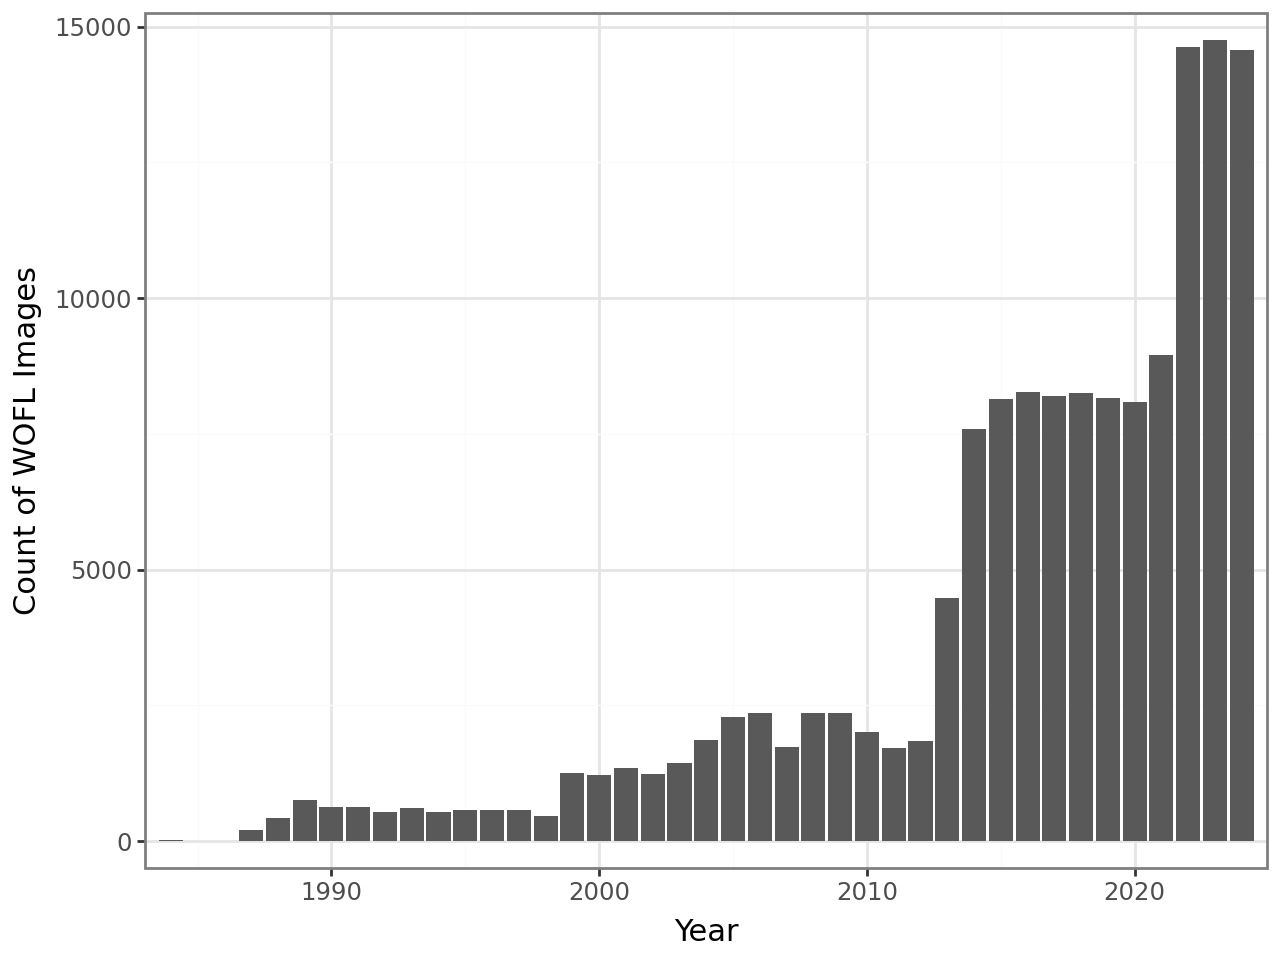

In [29]:
(
    pn.ggplot(df, pn.aes(x="year", y="number_of_items"))
    + pn.geom_bar(stat="identity")
    + pn.xlab("Year")
    + pn.ylab("Count of WOFL Images")
    + pn.scale_y_continuous(expand=(0, 500))
    + pn.scale_x_continuous(expand=(0, 0.5))
    + pn.theme_bw()
)

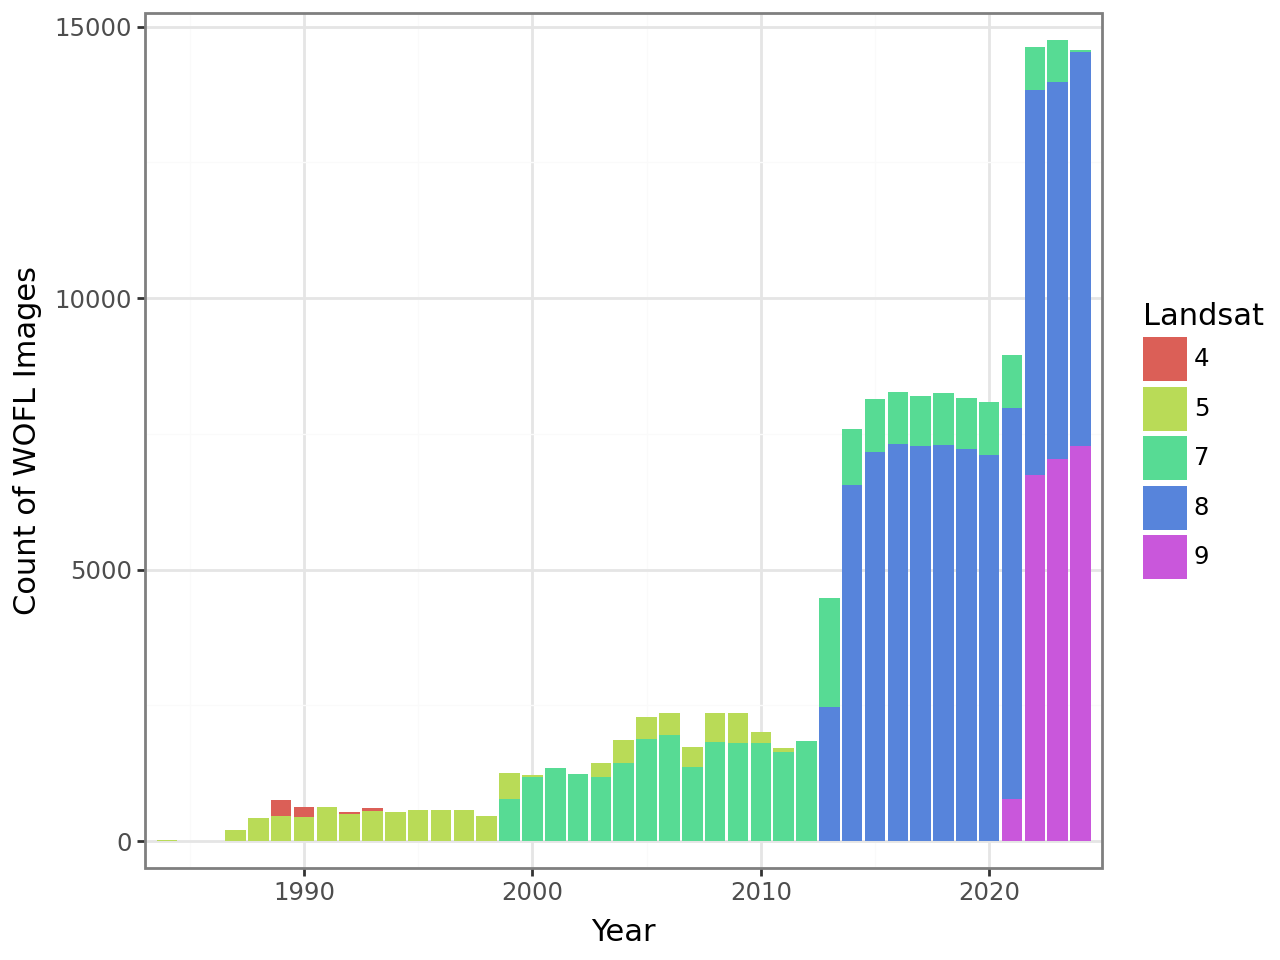

In [53]:
platform_df["Landsat"] = platform_df.platform.str[-1:]
(
    pn.ggplot(platform_df, pn.aes(x="year", y="number_of_items", fill="Landsat"))
    + pn.geom_bar(stat="identity")
    + pn.xlab("Year")
    + pn.ylab("Count of WOFL Images")
    + pn.scale_y_continuous(expand=(0, 500))
    + pn.scale_x_continuous(expand=(0, 0.5))
    + pn.theme_bw()
)